# 06 — Sentiment Scoring with FinBERT
Score Reddit posts and news headlines, aggregate to a daily sentiment index.


In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.nn.functional import softmax
import os

plt.rcParams['figure.dpi'] = 120
DEVICE = 'mps' if torch.backends.mps.is_available() else 'cpu'
print('Device:', DEVICE)

Device: mps


## 1. Load Models

Two models — each optimised for its source:
- **FinBERT** (`ProsusAI/finbert`) for news headlines — trained on financial news (Reuters, Bloomberg)
- **RoBERTa** (`cardiffnlp/twitter-roberta-base-sentiment-latest`) for Reddit — trained on social media text

In [26]:
# FinBERT — for news headlines
FINBERT_NAME = 'ProsusAI/finbert'
finbert_tokenizer = AutoTokenizer.from_pretrained(FINBERT_NAME)
finbert = AutoModelForSequenceClassification.from_pretrained(FINBERT_NAME).to(DEVICE)
finbert.eval()
print('FinBERT loaded. Labels:', finbert.config.id2label)

# RoBERTa — for Reddit posts (social media language)
ROBERTA_NAME = 'cardiffnlp/twitter-roberta-base-sentiment-latest'
roberta_tokenizer = AutoTokenizer.from_pretrained(ROBERTA_NAME)
roberta = AutoModelForSequenceClassification.from_pretrained(ROBERTA_NAME).to(DEVICE)
roberta.eval()
print('RoBERTa loaded. Labels:', roberta.config.id2label)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


FinBERT loaded. Labels: {0: 'positive', 1: 'negative', 2: 'neutral'}


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.pooler.dense.weight     | UNEXPECTED |  | 
roberta.pooler.dense.bias       | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


RoBERTa loaded. Labels: {0: 'negative', 1: 'neutral', 2: 'positive'}


## 2. Scoring function

In [27]:
def score_with_finbert(texts: list, batch_size: int = 32) -> pd.DataFrame:
    """
    Score texts with FinBERT. Used for financial news headlines.
    Label order: positive=0, negative=1, neutral=2
    sentiment_score = positive - negative
    """
    all_pos, all_neg, all_neu = [], [], []

    # Process in chunks of batch_size — GPU handles all texts in a chunk in parallel
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i + batch_size]

        # Tokenize: pad shorter texts to match the longest in this batch,
        # truncate anything over 512 tokens (BERT's hard limit)
        enc = finbert_tokenizer(batch, padding=True, truncation=True,
                                max_length=512, return_tensors='pt').to(DEVICE)

        with torch.no_grad():  # no gradients needed — inference only, saves memory
            # Run the batch through the model, then convert raw logits → probabilities
            # softmax over dim=-1 (the 3 class scores) so each row sums to 1
            # .cpu() moves the result off the GPU back to RAM; .numpy() for indexing
            probs = softmax(finbert(**enc).logits, dim=-1).cpu().numpy()

        # probs shape: (batch_size, 3) — each row is one text, each column one class
        all_pos.extend(probs[:, 0])  # FinBERT label 0 = positive
        all_neg.extend(probs[:, 1])  # FinBERT label 1 = negative
        all_neu.extend(probs[:, 2])  # FinBERT label 2 = neutral

    return pd.DataFrame({
        'positive': all_pos, 'negative': all_neg, 'neutral': all_neu,
        # score in [-1, 1]: +1 = fully positive, -1 = fully negative, 0 = neutral
        'sentiment_score': np.array(all_pos) - np.array(all_neg),
    })


def score_with_roberta(texts: list, batch_size: int = 32) -> pd.DataFrame:
    """
    Score texts with Twitter-RoBERTa. Used for Reddit posts.
    Label order: negative=0, neutral=1, positive=2
    sentiment_score = positive - negative
    """
    all_pos, all_neg, all_neu = [], [], []

    for i in range(0, len(texts), batch_size):
        batch = texts[i:i + batch_size]
        enc = roberta_tokenizer(batch, padding=True, truncation=True,
                                max_length=512, return_tensors='pt').to(DEVICE)
        with torch.no_grad():
            probs = softmax(roberta(**enc).logits, dim=-1).cpu().numpy()

        # RoBERTa label order differs from FinBERT — must map columns correctly
        # or sentiment scores will be flipped for Reddit posts
        all_neg.extend(probs[:, 0])  # RoBERTa label 0 = negative
        all_neu.extend(probs[:, 1])  # RoBERTa label 1 = neutral
        all_pos.extend(probs[:, 2])  # RoBERTa label 2 = positive

    return pd.DataFrame({
        'positive': all_pos, 'negative': all_neg, 'neutral': all_neu,
        'sentiment_score': np.array(all_pos) - np.array(all_neg),
    })


# ── Model comparison on same test texts ──────────────────────────────────────
test_texts = [
    'Silver is going to the moon! Buy buy buy!',       # retail bullish slang
    'Silver prices crash amid rising dollar and Fed hawkishness.',  # formal bearish
    'Silver traded flat today with low volume.',        # neutral
]

print('=== FinBERT (trained on financial news) ===')
print(score_with_finbert(test_texts)[['positive', 'negative', 'neutral', 'sentiment_score']].round(3).to_string())

print('\n=== RoBERTa (trained on social media) ===')
print(score_with_roberta(test_texts)[['positive', 'negative', 'neutral', 'sentiment_score']].round(3).to_string())


=== FinBERT (trained on financial news) ===
   positive  negative  neutral  sentiment_score
0     0.050     0.034    0.916            0.016
1     0.048     0.870    0.082           -0.822
2     0.061     0.882    0.058           -0.821

=== RoBERTa (trained on social media) ===
   positive  negative  neutral  sentiment_score
0     0.967     0.004    0.029            0.964
1     0.018     0.572    0.410           -0.554
2     0.046     0.146    0.808           -0.100


## 3. Score Reddit posts

In [28]:
import pandas as pd                                                                                                  
df = pd.read_csv('../data/raw/reddit_history.csv', parse_dates=['created_utc'])                                         
print(df.shape)                         
print(df['subreddit'].value_counts())                                                                                
print(df['created_utc'].min(), "→", df['created_utc'].max())                                                         
print(df['created_utc'].dt.year.value_counts().sort_index())

(657291, 8)
subreddit
Wallstreetsilver    433579
Silverbugs          223712
Name: count, dtype: int64
2015-03-28 02:59:50 → 2026-05-03 21:54:16
created_utc
2015      8595
2016     13285
2017     13184
2018     11322
2019     14075
2020     22672
2021    213745
2022    180650
2023     73578
2024     34827
2025     46872
2026     24486
Name: count, dtype: int64


In [29]:
df.head()

,id,subreddit,created_utc,title,selftext,score,num_comments,upvote_ratio
0,mdas9v,Wallstreetsilver,2021-03-25 22:58:49,2021 Silver Valiant from Royal Mint - Gorgeous...,NaN,37,7,0.96
1,mdarz7,Wallstreetsilver,2021-03-25 22:58:23,4 kilos silver shot. $28.15/oz and good for ba...,NaN,37,6,0.93
2,mdaqef,Wallstreetsilver,2021-03-25 22:56:06,T minus ? days and counting before launch,I spend a lot of time with WSS. \n\nIt feels ...,99,34,1.00
3,mdapph,Wallstreetsilver,2021-03-25 22:55:03,Sold Royal Caribbean shares for silver!,NaN,53,5,0.97
4,mdap83,Wallstreetsilver,2021-03-25 22:54:24,A Shout Out To Bison Bullion,I just placed an order and you can support fel...,16,6,0.84


In [30]:
import pandas as pd
                                                                                                  
reddit = pd.read_csv('../data/raw/reddit_history.csv', parse_dates=['created_utc'])
news   = pd.read_csv('../data/raw/news_gdelt.csv')                                                
news['date'] = pd.to_datetime(news['seendate'], format='%Y%m%dT%H%M%SZ', errors='coerce')
                                                                                                  
reddit_daily = reddit.set_index('created_utc').resample('D').size().rename('reddit_posts')
news_daily   = news.set_index('date').resample('D').size().rename('news_articles')                
                                                                                                  
counts = pd.concat([reddit_daily, news_daily], axis=1).fillna(0).astype(int)                      
print(counts.describe())                                                                          
counts.plot(figsize=(13, 4), title='Daily post/article counts')       

ParserError: Error tokenizing data. C error: Calling read(nbytes) on source failed. Try engine='python'.

In [ ]:
reddit_path = '../data/raw/reddit_history.csv'

if os.path.exists(reddit_path):
    reddit = pd.read_csv(reddit_path, parse_dates=['created_utc'])
    reddit = reddit.dropna(subset=['title'])

    # Combine title + first 100 chars of body for more signal
    reddit['text'] = reddit['title'] + '. ' + reddit['selftext'].fillna('').str[:100]

    # Use RoBERTa — better suited for Reddit's informal language than FinBERT
    print(f'Scoring {len(reddit):,} Reddit posts with RoBERTa...')
    scores = score_with_roberta(reddit['text'].tolist())

    # Attach sentiment columns to the original DataFrame (reset index so concat aligns)
    reddit = pd.concat([reddit.reset_index(drop=True), scores], axis=1)
    reddit['date'] = pd.to_datetime(reddit['created_utc']).dt.date

    # Weight by upvotes — a post with 5000 upvotes carries more community signal
    # than one with 1; clip at 1 so downvoted/zero-score posts still contribute minimally
    reddit['weight'] = reddit['score'].clip(lower=1)
    reddit['weighted_sentiment'] = reddit['sentiment_score'] * reddit['weight']

    daily_reddit = (
        reddit.groupby('date')
        .agg(
            reddit_sentiment=('weighted_sentiment', 'sum'),  # sum of weight * sentiment
            reddit_weight_sum=('weight', 'sum'),             # sum of weights (denominator)
            reddit_post_count=('sentiment_score', 'count'),  # number of posts that day
        )
        # Divide to get weighted average — keeps the score in [-1, 1] regardless of post volume
        .assign(reddit_sentiment=lambda d: d['reddit_sentiment'] / d['reddit_weight_sum'])
    )
    daily_reddit.index = pd.to_datetime(daily_reddit.index)
    print(daily_reddit.tail())
else:
    print('No Reddit history file — run collect_reddit.py first.')
    daily_reddit = pd.DataFrame()


Scoring 657,291 Reddit posts with RoBERTa...


KeyboardInterrupt: 

### Methodological note — English-only filter on GDELT

GDELT is a **multilingual news aggregator** — its silver-related coverage spans
dozens of languages (Spanish, Mandarin, Russian, Arabic, etc.). In our fetch,
roughly 85% of articles are non-English. **FinBERT is trained exclusively on
English financial text** (Reuters, Bloomberg, financial filings); running it on
non-English headlines produces uninterpretable scores, since the model has no
representation of those languages.

The `language == 'English'` filter applied below is therefore a **hard model
requirement**, not a methodological choice. The asymmetry with the Reddit
pipeline (no filter there) is justified by the different language characteristics
of the two sources:

| Source  | Language characteristic              | Filter applied?               | Reason                              |
|---------|--------------------------------------|-------------------------------|-------------------------------------|
| Reddit  | Implicitly English (subreddit-gated) | No                            | Source pre-filtered by community    |
| GDELT   | Multilingual (English ≈ 15%)         | Yes (`language == 'English'`) | Required by FinBERT's training data |

A multilingual model (e.g. XLM-R fine-tuned for finance) would let us score the
non-English ~85% as well, but at the cost of mixing model regimes — we accept
the smaller English-only sample for cross-document comparability.

In [ ]:
news_path = '../data/raw/news_gdelt.csv'

if os.path.exists(news_path):
    news = pd.read_csv(news_path, parse_dates=['seendate'])  # GDELT uses 'seendate' not 'datetime'
    news = news.dropna(subset=['title'])  # can't score a headline that doesn't exist

    # FinBERT is English-only — filter out non-English articles before scoring
    # to avoid meaningless scores on foreign-language text
    if 'language' in news.columns:
        before = len(news)
        news = news[news['language'] == 'English']
        print(f'Language filter: {before:,} → {len(news):,} articles ({before - len(news):,} dropped)')

    print(f'Scoring {len(news):,} news headlines...')
    news_scores = score_with_finbert(news['title'].tolist())  # titles only — GDELT has no body text

    # reset_index on both sides so rows align correctly before concatenating
    news = pd.concat([news.reset_index(drop=True), news_scores], axis=1)

    # seendate is a full timestamp — strip to date only so we can group by day
    news['date'] = pd.to_datetime(news['seendate']).dt.date

    daily_news = (
        news.groupby('date')['sentiment_score']
        .agg(['mean', 'count'])  # mean sentiment + article count for that day
        .rename(columns={'mean': 'news_sentiment', 'count': 'news_article_count'})
        # no upvote weighting here — all news articles treated equally
    )
    # groupby returns plain date strings; convert to datetime to align with other DataFrames
    daily_news.index = pd.to_datetime(daily_news.index)
    print(daily_news.tail())
else:
    print('No GDELT news file — run collect_news.py first.')
    daily_news = pd.DataFrame()


Language filter: 62,558 → 9,049 articles (53,509 dropped)
Scoring 9,049 news headlines...
            news_sentiment  news_article_count
date                                          
2026-04-29        0.200282                  15
2026-04-30        0.187867                   6
2026-05-01       -0.148482                   5
2026-05-02       -0.239015                   3
2026-05-03        0.011428                   2


In [ ]:
# TODO 

## 5. Combine into daily sentiment index

In [ ]:
sentiment_frames = [f for f in [daily_reddit, daily_news] if not f.empty]

if sentiment_frames:
    daily_sentiment = pd.concat(sentiment_frames, axis=1).sort_index()

    # Composite score: equal weight of Reddit + news (can tune later)
    cols = [c for c in ['reddit_sentiment', 'news_sentiment'] if c in daily_sentiment.columns]
    # TODO: Add another sentiment score, so one will have the gdelt data and the other one will have the gkg data, which is more noisy but has much higher coverage.
    daily_sentiment['sentiment_score'] = daily_sentiment[cols].mean(axis=1)

    # Forward-fill weekends/gaps (no posts on weekends)
    # Asier: make sure this is sensible — if we have a gap of several days, should we really carry forward the last sentiment score?
    daily_sentiment = daily_sentiment.resample('B').ffill()  # business days

    os.makedirs('../data/processed', exist_ok=True)
    daily_sentiment.to_csv('../data/processed/daily_sentiment.csv')
    print('Saved:', daily_sentiment.shape)
    daily_sentiment.head()
else:
    print('No sentiment data to combine yet.')


Saved: (2896, 6)


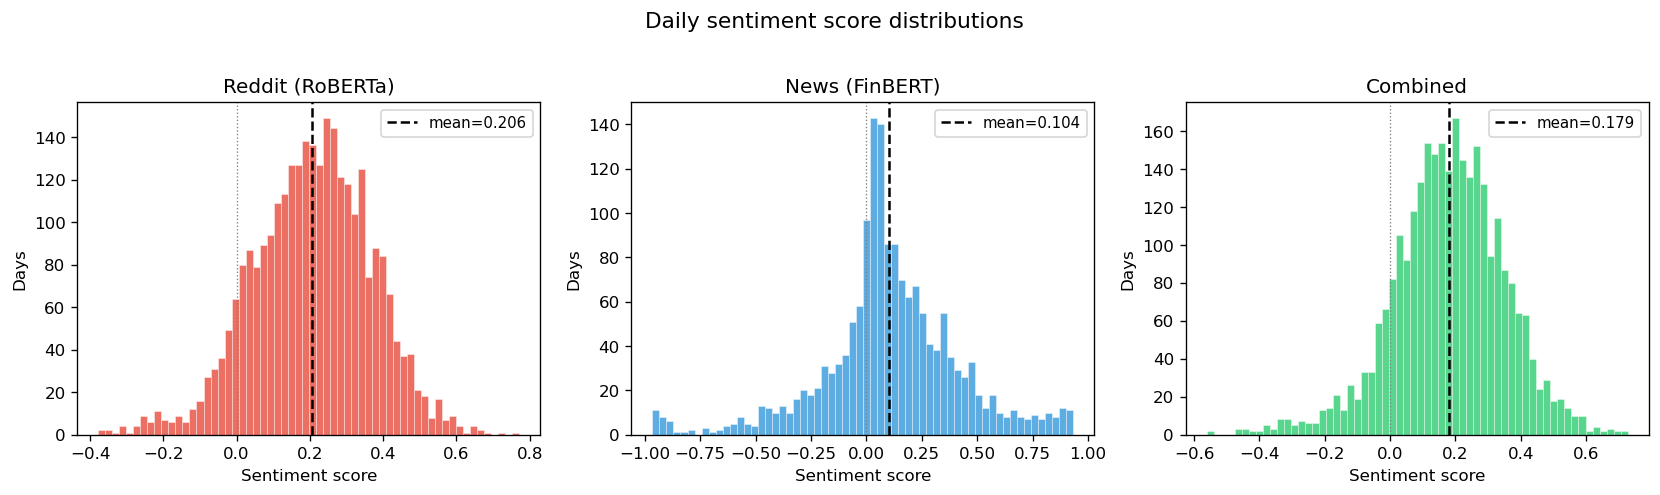

       reddit_sentiment  news_sentiment  sentiment_score
count          2895.000        1642.000         2895.000
mean              0.206           0.104            0.179
std               0.161           0.312            0.172
min              -0.378          -0.966           -0.562
25%               0.101          -0.023            0.076
50%               0.213           0.082            0.183
75%               0.318           0.266            0.291
max               0.772           0.934            0.727


In [ ]:
## 6. Sentiment distribution

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, col, label, color in zip(
    axes,
    ['reddit_sentiment', 'news_sentiment', 'sentiment_score'],
    ['Reddit (RoBERTa)', 'News (FinBERT)', 'Combined'],
    ['#e74c3c', '#3498db', '#2ecc71'],
):
    data = daily_sentiment[col].dropna()
    ax.hist(data, bins=60, color=color, alpha=0.8, edgecolor='white', linewidth=0.3)
    ax.axvline(data.mean(), color='black', lw=1.5, ls='--', label=f'mean={data.mean():.3f}')
    ax.axvline(0, color='grey', lw=0.8, ls=':')
    ax.set_title(label)
    ax.set_xlabel('Sentiment score')
    ax.set_ylabel('Days')
    ax.legend(fontsize=9)

plt.suptitle('Daily sentiment score distributions', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(daily_sentiment[['reddit_sentiment', 'news_sentiment', 'sentiment_score']].describe().round(3))

## 7. GKG news tone — full-window backfill (exploratory)

`collect_news_gkg.py` pulls the full **2015–2026** silver-news window from the
GDELT GKG and carries GDELT's own **document tone**. The DOC API in §4 only
reaches 2017 and has no tone; GKG has no usable titles, so FinBERT isn't an option
here — tone is the signal instead.

Two problems handled below:
- **Relevance** — URL-slug `silver` drags in jewelry (JTV), `Silver Lake` the PE
  firm, `Adam Silver`, etc. We filter to a curated allowlist of precious-metals /
  commodity-news domains (~90% precision; the rest can't be cleaned without titles).
- **Scale** — GKG tone (≈ −10…+10) is squashed to [−1, 1] via `tanh` so it sits on
  the same scale as the FinBERT `news_sentiment`.

Exploratory for now — **not** wired into the daily index in §5.

In [76]:
# ── Load raw GKG tone file ──────────────────────────────────────────────
gkg = pd.read_csv('../data/raw/news_gkg.csv')
gkg['date'] = pd.to_datetime(gkg['seendate'], format='%Y%m%dT%H%M%SZ', errors='coerce')

print(f'rows      : {len(gkg):,}')
print(f'date span : {gkg.date.min():%Y-%m-%d} -> {gkg.date.max():%Y-%m-%d}')
print(f'language  : {gkg.language.value_counts().to_dict()}')
print(f'tone      : mean {gkg.tone.mean():+.2f}  std {gkg.tone.std():.2f}  '
      f'[{gkg.tone.min():.1f}, {gkg.tone.max():.1f}]')
print('\ntop 15 domains (raw — note the non-commodity noise, e.g. jtv.com = Jewelry TV):')
print(gkg.domain.value_counts().head(15).to_string())

# English-only for the whole section: FinBERT is English-only, and we keep the tone
# path on the same sample so every signal in this section is comparable.
# (language is per-article, not per-domain.)
gkg = gkg[gkg['language'] == 'English'].copy()
print(f'\nfiltered to English: {len(gkg):,} rows')

rows      : 619,654
date span : 2015-02-18 -> 2026-05-03
language  : {'English': 518612, 'Other': 101042}
tone      : mean +0.61  std 3.52  [-91.0, 36.7]

top 15 domains (raw — note the non-commodity noise, e.g. jtv.com = Jewelry TV):
domain
jtv.com                  37708
finanznachrichten.de      8813
indiatimes.com            8643
mcxcontrol.com            8345
silverbirdtv.com          7318
yahoo.com                 6342
kitco.com                 6025
silver.ru                 4973
business-standard.com     4624
iheart.com                4481
4-traders.com             4307
prnewswire.com            3973
marketwatch.com           3152
marketscreener.com        3138
dailypolitical.com        3098

filtered to English: 518,612 rows


### Relevance filter — precious-metals domain allowlist

The economic-theme filter in the SQL can't separate the metal from jewelry retail
(JTV is the single biggest domain), finance firms named "Silver" (Silver Lake,
Silvergate), or people/places (Adam Silver, Silver City). A curated allowlist of
dedicated commodity / precious-metals news domains gets relevance to ~90% while
keeping full weekly coverage (~73 articles/week, ≤1 empty week).

The allowlist is curated from what's *visible* in this data, so it's slightly
self-selected — edit `RELEVANT_DOMAINS` and re-run to tune. Kept at the feature
layer; the raw file is untouched.

In [67]:
# Curated precious-metals / commodity-news domains (audit & extend freely).
# RELEVANT_DOMAINS = {
#     'kitco.com', 'goldseiten.de', 'goldseiten.at', 'juniorminingnetwork.com',
#     'coinnews.net', 'mcxcontrol.com', 'marketscreener.com', '4-traders.com',
#     'finanznachrichten.de', 'aktiencheck.de', 'bullionvault.com', 'mineweb.com',
#     'silverseek.com', 'goldprice.org', 'sharpspixley.com', 'goldcore.com',
#     'smaulgld.com', 'livecharts.co.uk', 'investing.com',
# }

RELEVANT_DOMAINS = {
    # original curated set
    'kitco.com', 'goldseiten.de', 'goldseiten.at', 'juniorminingnetwork.com',
    'coinnews.net', 'mcxcontrol.com', 'marketscreener.com', '4-traders.com',
    'finanznachrichten.de', 'aktiencheck.de', 'bullionvault.com', 'mineweb.com',
    'silverseek.com', 'goldprice.org', 'sharpspixley.com', 'goldcore.com',
    'smaulgld.com', 'livecharts.co.uk', 'investing.com',
    # + mining / metals / commodity outlets (sample-verified on-topic)
    'proactiveinvestors.com', 'proactiveinvestors.com.au', 'proactiveinvestors.co.uk',
    'mining.com', 'mining-journal.com', 'miningweekly.com', 'miningnews.net',
    'canadianminingjournal.com', 'northernminer.com', 'miningmx.com', 'nxtmine.com',
    'yourminingnews.com', 'republicofmining.com', 'mining-technology.com',
    'metal.com', 'oilngold.com', 'commodityonline.com', 'resourceinvestor.com',
    'streetwisereports.com', 'streetwisereport.com', 'silverinvestingnews.com',
    'yourmetalnews.com', 'bulliondesk.com',
}

gkg_rel = gkg[gkg.domain.isin(RELEVANT_DOMAINS)].copy()
print(f'kept {len(gkg_rel):,} / {len(gkg):,} rows ({len(gkg_rel)/len(gkg)*100:.0f}%)')
print('\nkept by domain:')
print(gkg_rel.domain.value_counts().to_string())
print('\n10 random kept URLs (eyeball relevance):')
for u in gkg_rel.url.dropna().sample(10, random_state=0):
    print('  ', u[:95])

kept 46,152 / 518,612 rows (9%)

kept by domain:
domain
mcxcontrol.com               8343
finanznachrichten.de         6738
kitco.com                    6025
4-traders.com                4303
marketscreener.com           3138
juniorminingnetwork.com      2785
goldseiten.de                2472
proactiveinvestors.com       1625
coinnews.net                 1450
mining-journal.com            867
investing.com                 861
proactiveinvestors.com.au     713
mining.com                    707
oilngold.com                  636
metal.com                     636
miningnews.net                592
livecharts.co.uk              473
proactiveinvestors.co.uk      459
canadianminingjournal.com     426
miningweekly.com              342
bullionvault.com              338
commodityonline.com           298
mining-technology.com         244
silverinvestingnews.com       181
yourminingnews.com            175
yourmetalnews.com             165
resourceinvestor.com          151
northernminer.com         

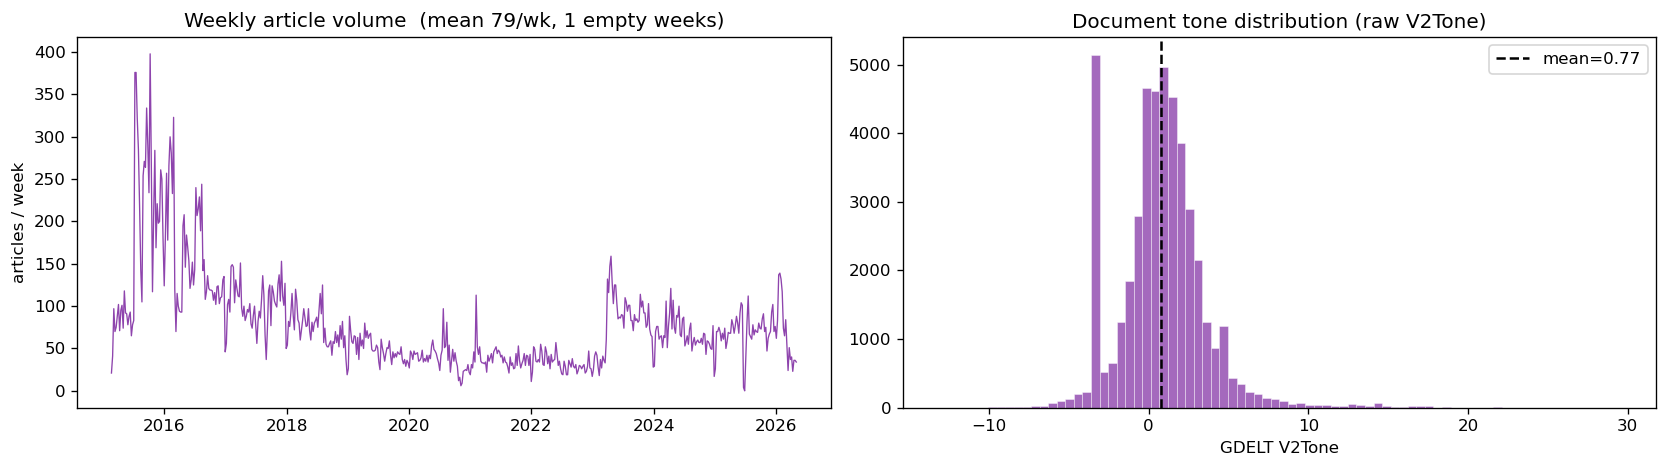

In [68]:
# ── EDA: weekly article volume + tone distribution (after filter) ───────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

wk_vol = gkg_rel.set_index('date').resample('W-FRI').size()
axes[0].plot(wk_vol.index, wk_vol.values, lw=0.8, color='#8e44ad')
axes[0].set_title(f'Weekly article volume  (mean {wk_vol.mean():.0f}/wk, '
                  f'{int((wk_vol == 0).sum())} empty weeks)')
axes[0].set_ylabel('articles / week')

axes[1].hist(gkg_rel.tone.dropna(), bins=80, color='#8e44ad', alpha=0.8,
             edgecolor='white', linewidth=0.3)
axes[1].axvline(gkg_rel.tone.mean(), color='black', ls='--', lw=1.5,
                label=f'mean={gkg_rel.tone.mean():.2f}')
axes[1].set_title('Document tone distribution (raw V2Tone)')
axes[1].set_xlabel('GDELT V2Tone'); axes[1].legend()
plt.tight_layout(); plt.show()

### Tone → [−1, 1] and weekly aggregation

`tanh(tone / 4)` squashes the raw tone onto FinBERT's `news_sentiment` scale
(std ≈ 0.5). Weekly mean on the W-FRI calendar matches the rest of the pipeline.

In [69]:
TONE_SCALE = 4.0  # tanh(tone/k): k≈4 gives std≈0.5, matching FinBERT news_sentiment

gkg_rel['gkg_sentiment'] = np.tanh(gkg_rel['tone'] / TONE_SCALE)
gkg_weekly = (
    gkg_rel.set_index('date')['gkg_sentiment']
           .resample('W-FRI').mean()
           .rename('gkg_news_sentiment')
)
print(gkg_weekly.describe().round(3).to_string())
print('\nspan:', gkg_weekly.index.min().date(), '->', gkg_weekly.index.max().date())

count    584.000
mean       0.209
std        0.167
min       -0.498
25%        0.171
50%        0.236
75%        0.299
max        0.586

span: 2015-02-20 -> 2026-05-01


### GKG tone vs FinBERT — do they agree on the 2017+ overlap?

If weekly GKG tone tracks the FinBERT `news_sentiment`, the two are
interchangeable and the 2015–2017 backfill is safe to splice on. If they diverge,
the methodology break matters and the choice must be deliberate. (`daily_news` is
the FinBERT daily series built in §4.)

overlap weeks: 406    correlation: -0.048


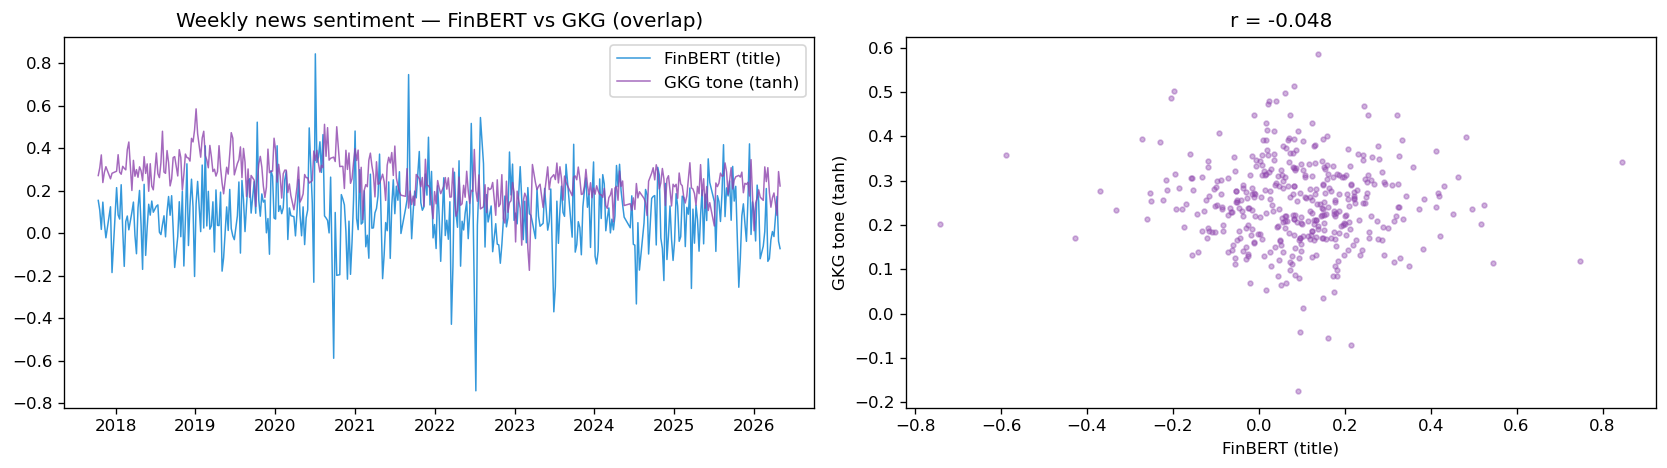

In [70]:
# FinBERT weekly (from §4 daily_news) vs GKG weekly tone, on their overlap.
finbert_weekly = daily_news['news_sentiment'].resample('W-FRI').mean()

cmp = pd.concat([finbert_weekly.rename('finbert'),
                 gkg_weekly.rename('gkg')], axis=1).dropna()
r = cmp['finbert'].corr(cmp['gkg'])
print(f'overlap weeks: {len(cmp)}    correlation: {r:+.3f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(cmp.index, cmp['finbert'], lw=0.9, label='FinBERT (title)', color='#3498db')
axes[0].plot(cmp.index, cmp['gkg'], lw=0.9, label='GKG tone (tanh)', color='#8e44ad', alpha=0.8)
axes[0].set_title('Weekly news sentiment — FinBERT vs GKG (overlap)'); axes[0].legend()

axes[1].scatter(cmp['finbert'], cmp['gkg'], s=8, alpha=0.4, color='#8e44ad')
axes[1].set_xlabel('FinBERT (title)'); axes[1].set_ylabel('GKG tone (tanh)')
axes[1].set_title(f'r = {r:+.3f}')
plt.tight_layout(); plt.show()

### Lagged GKG news tone vs silver weekly return

Self-contained — rebuilds both weekly series from raw, then `corr(news_{t-k}, ret_t)`.
`k > 0` is the predictive direction (past news vs current return); a clean null here
is semi-strong-form-EMH evidence, not a failure.

overlap weeks: 584    significance ~ +/-0.083

lag_k
0    0.046
1    0.008
2   -0.037
3   -0.021
4    0.034
5    0.031


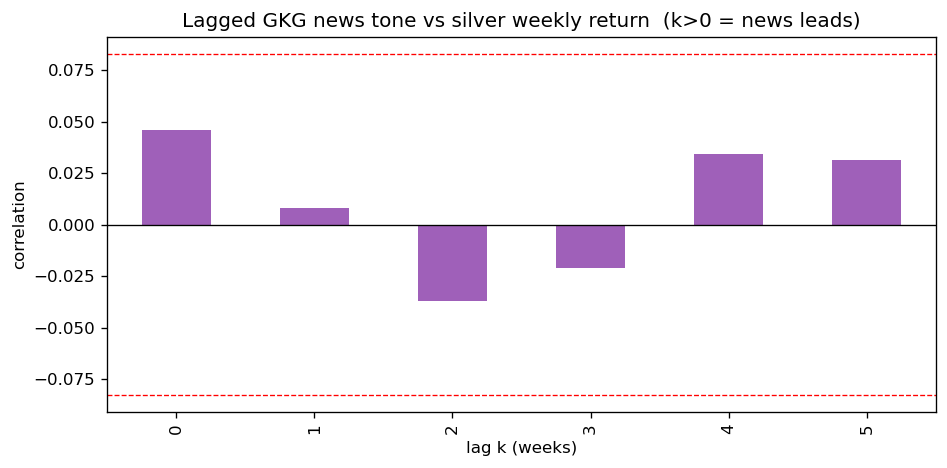

In [71]:
# Self-contained: silver weekly return + GKG weekly news tone from raw files.
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

# silver weekly log-return = W-FRI sum of daily log-returns (project convention)
px  = pd.read_csv('../data/raw/daily_prices.csv', index_col=0, parse_dates=True)['silver']
ret = np.log(px).diff().resample('W-FRI').sum().rename('silver_ret')

# weekly GKG news tone: allowlist -> tanh(tone/4) -> W-FRI mean
# ALLOW = {'kitco.com','goldseiten.de','goldseiten.at','juniorminingnetwork.com',
#          'coinnews.net','mcxcontrol.com','marketscreener.com','4-traders.com',
#          'finanznachrichten.de','aktiencheck.de','bullionvault.com','mineweb.com',
#          'silverseek.com','goldprice.org','sharpspixley.com','goldcore.com',
#          'smaulgld.com','livecharts.co.uk','investing.com'}
ALLOW = {
    # original curated set
    'kitco.com', 'goldseiten.de', 'goldseiten.at', 'juniorminingnetwork.com',
    'coinnews.net', 'mcxcontrol.com', 'marketscreener.com', '4-traders.com',
    'finanznachrichten.de', 'aktiencheck.de', 'bullionvault.com', 'mineweb.com',
    'silverseek.com', 'goldprice.org', 'sharpspixley.com', 'goldcore.com',
    'smaulgld.com', 'livecharts.co.uk', 'investing.com',
    # + mining / metals / commodity outlets (sample-verified on-topic)
    'proactiveinvestors.com', 'proactiveinvestors.com.au', 'proactiveinvestors.co.uk',
    'mining.com', 'mining-journal.com', 'miningweekly.com', 'miningnews.net',
    'canadianminingjournal.com', 'northernminer.com', 'miningmx.com', 'nxtmine.com',
    'yourminingnews.com', 'republicofmining.com', 'mining-technology.com',
    'metal.com', 'oilngold.com', 'commodityonline.com', 'resourceinvestor.com',
    'streetwisereports.com', 'streetwisereport.com', 'silverinvestingnews.com',
    'yourmetalnews.com', 'bulliondesk.com',
}

g = pd.read_csv('../data/raw/news_gkg.csv')
g['date'] = pd.to_datetime(g['seendate'], format='%Y%m%dT%H%M%SZ', errors='coerce')
g = g[g.domain.isin(ALLOW) & (g['language'] == 'English')]
news = np.tanh(g.set_index('date')['tone'] / 4).resample('W-FRI').mean().rename('news')

df  = pd.concat([news, ret], axis=1).dropna()
n   = len(df)
sig = 2 / np.sqrt(n)   # ~5% significance threshold for a single correlation

# corr(news_{t-k}, ret_t): k>0 = lagged (past) news vs current return
lags = range(0, 6)
res  = pd.Series({k: df['news'].shift(k).corr(df['silver_ret']) for k in lags},
                 name='corr(news_{t-k}, ret_t)')
res.index.name = 'lag_k'
print(f'overlap weeks: {n}    significance ~ +/-{sig:.3f}\n')
print(res.round(3).to_string())

ax = res.plot.bar(figsize=(8, 4), color='#8e44ad', alpha=0.85, legend=False)
ax.axhline(0, color='k', lw=0.8)
ax.axhline(sig, color='r', ls='--', lw=0.8); ax.axhline(-sig, color='r', ls='--', lw=0.8)
ax.set_title('Lagged GKG news tone vs silver weekly return  (k>0 = news leads)')
ax.set_xlabel('lag k (weeks)'); ax.set_ylabel('correlation')
plt.tight_layout(); plt.show()

### GKG articles in the filtered set

GKG has no titles, so these "names" are derived from the **URL slug** — a readable
proxy for eyeballing what feeds the tone signal. Reuses `gkg_rel` from §7, so it
reflects the current `RELEVANT_DOMAINS`.

In [75]:
import re
from urllib.parse import urlparse

def slug_name(u):
    """Readable article name from a URL slug (GKG has no titles)."""
    if not isinstance(u, str):
        return ''
    segs = [s for s in urlparse(u).path.split('/') if s]
    if not segs:
        return ''
    seg = max(segs, key=lambda s: sum(c.isalpha() for c in s))   # headline-like segment
    seg = re.sub(r'\.(html?|aspx|php|shtml)$', '', seg, flags=re.I)
    seg = re.sub(r'[-_+]+', ' ', seg)
    seg = re.sub(r'\b\d{4,}\b', '', seg)                       # drop long id numbers
    return seg.strip()[:90]

view = (gkg_rel.assign(article=gkg_rel['url'].map(slug_name))
              .loc[:, ['date', 'domain', 'tone', 'article']]
              .assign(date=lambda d: d['date'].dt.date)
              .round({'tone': 2}))
print(f'{len(view):,} GKG articles in the current filtered set '
      f'(titles unavailable — URL-slug names)\n')
with pd.option_context('display.max_rows', 60, 'display.max_colwidth', 95, 'display.width', 170):
    display(view.sample(40, random_state=1).sort_values('date').reset_index(drop=True))

46,152 GKG articles in the current filtered set (titles unavailable — URL-slug names)



,date,domain,tone,article
0,2015-06-05,goldseiten.de,-1.11,Silver Standard Announces Reduction in Holdings of Pretium Resources Inc.
1,2015-07-24,mcxcontrol.com,-3.47,research livesell silver tgt 450 sl34031 call7096132662 3
2,2015-07-31,kitco.com,1.27,Where are the Stops Friday July 31 Gold and Silver
3,2015-11-12,metal.com,-4.88,scrap gold silver and platinum prices declined on nov. 10
4,2015-12-11,mcxcontrol.com,-3.47,dobt miss jackpot silver buy abv sell blw
5,2015-12-22,mcxcontrol.com,-3.47,research livesell silver tgt sl call7096132662 www researchlive in
6,2015-12-29,4-traders.com,0.33,Santacruz Silver Mining Announces Short Term Loan with Trafigura
7,2016-01-19,mcxcontrol.com,-3.47,om commodities tdy gold silver by call tg hit daily 20000profit
8,2016-01-28,goldseiten.de,0.90,Panoro Announces US 140 Million Precious Metals Streaming Financing With Silver Wheaton
9,2016-03-15,finanznachrichten.de,1.20,nsr report finds lower satellite capacity prices unlocking 3g 4g backhaul opportunities do


In [73]:
# FinBERT on GKG article names (URL slugs) — method-matched to the DOC news signal.
import re
from urllib.parse import urlparse

def slug_name(u):
    # readable article name from a URL slug (GKG has no titles)
    if not isinstance(u, str):
        return ''
    segs = [s for s in urlparse(u).path.split('/') if s]
    if not segs:
        return ''
    seg = max(segs, key=lambda s: sum(c.isalpha() for c in s))   # headline-like segment
    seg = re.sub(r'\.(html?|aspx|php|shtml)$', '', seg, flags=re.I)
    seg = re.sub(r'[-_+]+', ' ', seg)
    seg = re.sub(r'\b\d{4,}\b', '', seg)                       # drop long id numbers
    return seg.strip()[:90]

gkg_names = gkg_rel.assign(name=gkg_rel['url'].map(slug_name))
gkg_names = gkg_names[gkg_names['name'].str.len() > 0].copy()

# Score each UNIQUE slug once (slugs repeat across rows), then map back — saves compute.
uniq = gkg_names['name'].drop_duplicates().tolist()
print(f'scoring {len(uniq):,} unique slug names with FinBERT '
      f'({len(gkg_names):,} articles)... (a few minutes)')
scored = score_with_finbert(uniq)
gkg_names['finbert'] = gkg_names['name'].map(dict(zip(uniq, scored['sentiment_score'])))

gkg_finbert_weekly = (gkg_names.set_index('date')['finbert']
                      .resample('W-FRI').mean().rename('gkg_finbert'))
print(gkg_finbert_weekly.describe().round(3).to_string())

scoring 39,627 unique slug names with FinBERT (46,151 articles)... (a few minutes)
count    584.000
mean       0.142
std        0.087
min       -0.187
25%        0.088
50%        0.136
75%        0.194
max        0.482


In [74]:
# Correlations: FinBERT-on-GKG vs the GDELT/DOC FinBERT signal, and lagged vs silver return.
import numpy as np

doc_finbert_weekly = daily_news['news_sentiment'].resample('W-FRI').mean().rename('doc_finbert')
px  = pd.read_csv('../data/raw/daily_prices.csv', index_col=0, parse_dates=True)['silver']
ret = np.log(px).diff().resample('W-FRI').sum().rename('silver_ret')

# (a) agreement — both are FinBERT, so this controls for method and isolates the article set.
agree = pd.concat([gkg_finbert_weekly, doc_finbert_weekly], axis=1).dropna()
print(f"FinBERT-GKG  vs  FinBERT-DOC :  r = {agree['gkg_finbert'].corr(agree['doc_finbert']):+.3f}  (n={len(agree)})")
print('   reference - GKG *tone* vs FinBERT-DOC was ~ +0.03\n')

# (b) lagged corr(FinBERT-GKG_{t-k}, silver_ret_t)
d = pd.concat([gkg_finbert_weekly, ret], axis=1).dropna(); n = len(d); sig = 2 / np.sqrt(n)
print(f'FinBERT-GKG  ->  silver return  (n={n}, sig +/-{sig:.3f})')
for k in range(6):
    r = d['gkg_finbert'].shift(k).corr(d['silver_ret'])
    star = '  *SIG*' if abs(r) > sig else ''
    print(f'   k{k}: {r:+.3f}{star}')

FinBERT-GKG  vs  FinBERT-DOC :  r = +0.048  (n=406)
   reference - GKG *tone* vs FinBERT-DOC was ~ +0.03

FinBERT-GKG  ->  silver return  (n=584, sig +/-0.083)
   k0: +0.173  *SIG*
   k1: -0.052
   k2: +0.002
   k3: -0.011
   k4: +0.034
   k5: -0.020


### Why FinBERT on the slug, not the raw GKG tone

`V2Tone` is a **general-news affect score over the whole article body**, not a
financial-sentiment model — so it diverges from the headline's directional message
in three ways:

- **Headline vs body** — a bullish headline on a hedged article scores negative
  (`Materials Shares Rise as Gold Settles Higher` → tone −5.7;
  `gold and silver declines on prospect of US rate hike` → tone +5.9).
- **Finance polysemy** — `failed breakdown… a bullish signal` reads negative because
  GDELT's lexicon flags "failed"/"breakdown"; `costs fall` reads bearish even though
  falling costs are good news.
- **Promotional copy** — tip-sheet pages score on "profit/buy/gain" marketing
  language, not on any directional view.

That's why tone barely correlates with FinBERT (r ≈ 0.03) or with returns. FinBERT
reads the **directional headline message in a financial context**, so we use
**FinBERT on the slug name** as the GKG sentiment signal and keep raw `tone` only as
a reference column. The cell below shows cases where the two disagree in sign.

In [ ]:
# Where GKG tone and FinBERT-on-slug disagree in SIGN.
# FinBERT tracks the headline; tone tracks whole-body affect.
ex = gkg_names[['date', 'domain', 'tone', 'finbert', 'name']].dropna()

bull_title_neg_tone = ex[(ex.finbert > 0.3) & (ex.tone < -3)].sort_values('tone').head(6)
bear_title_pos_tone = ex[(ex.finbert < -0.3) & (ex.tone > 3)].sort_values('tone', ascending=False).head(6)

print('FinBERT reads the headline BULLISH, but GKG tone is NEGATIVE:')
for _, r in bull_title_neg_tone.iterrows():
    print(f'  finbert {r.finbert:+.2f}  tone {r.tone:+6.2f} | {r["name"][:80]}')
print('\nFinBERT reads the headline BEARISH, but GKG tone is POSITIVE:')
for _, r in bear_title_pos_tone.iterrows():
    print(f'  finbert {r.finbert:+.2f}  tone {r.tone:+6.2f} | {r["name"][:80]}')